In [36]:
# imports&settings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import numpy as np

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [37]:
# loading and inspecting the data
df = pd.read_csv(r"C:\Users\dimit\Documents\world-economic-indicators-eda\data\macro_indicators.csv") #"r" tells python to treat the string as a raw string, which is crucial since we have to use "\" = special character, inside the string for the file path.

print("=== SHAPE ===")
print(df.shape)

print("\n=== FIRST 5 ROWS ===")
display(df.head()) # display() to render the table nicely, Jupyter specific

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== MISSING VALUES % ===")
print(df.isnull().mean().mul(100).round(1))


=== SHAPE ===
(1080, 7)

=== FIRST 5 ROWS ===


,country,country_code,year,gdp_growth,inflation,interest_rate,unemployment
0,Argentina,ARG,2002,-11.842314,NaN,NaN,NaN
1,Argentina,ARG,2003,7.718390,NaN,NaN,15.360
2,Argentina,ARG,2004,7.929517,NaN,NaN,13.522
3,Argentina,ARG,2005,7.738981,NaN,NaN,11.506
4,Argentina,ARG,2006,6.941852,NaN,NaN,10.078



=== DATA TYPES ===
country              str
country_code         str
year               int64
gdp_growth       float64
inflation        float64
interest_rate    float64
unemployment     float64
dtype: object

=== MISSING VALUES ===
country            0
country_code       0
year               0
gdp_growth        45
inflation         61
interest_rate    458
unemployment      45
dtype: int64

=== MISSING VALUES % ===
country           0.0
country_code      0.0
year              0.0
gdp_growth        4.2
inflation         5.6
interest_rate    42.4
unemployment      4.2
dtype: float64


In [38]:
# treat this folder as home base for the rest of the notebook
import os
os.chdir(r"C:\Users\dimit\Documents\world-economic-indicators-eda")
print("Working directory set to:", os.getcwd())

Working directory set to: C:\Users\dimit\Documents\world-economic-indicators-eda


In [39]:
# clean the data
# creating a new df: df_clean
df_clean = df.dropna(
    subset=["gdp_growth", "inflation", "unemployment", "interest_rate"], # tells dropna which columns to look at
    how="all" # only drop if all listed columns are Na
) # if all 4 columns are Na, drop the row

# now, we still have some rows where 1-3 of the 4 columns could be missing, and we have to fill them
# fill remaining missing values with each country's own historical average
# this is better than using the global average
# because e.g. Turkey's average inflation is very different from Japan's
for col in ["gdp_growth", "inflation", "unemployment", "interest_rate"]:
    df_clean[col] = df_clean.groupby("country")[col].transform(
        lambda x: x.fillna(x.mean())
    )

# now, let's remove extreme statistical outliers (beyond 3 standard deviations)
# a "standard deviation" measures how spread out values are from the mean
# values more than 3 std away are almost certainly data errors or extreme events
# that would distort our charts and statistics
for col in ["gdp_growth", "inflation", "unemployment", "interest_rate"]:
    mean = df_clean[col].mean()
    std  = df_clean[col].std()
    before = len(df_clean)
    df_clean = df_clean[
        (df_clean[col] >= mean - 3 * std) & (df_clean[col] <= mean + 3 * std)  # columns where the value is within 3 standard deviations of the mean
        | df_clean[col].isna() # we don't want to accidentally drop missing values here
        # why? (value >= mean - 3*std) & (value <= mean + 3*std) returns False for Na values automatically in pandas
        # "|" is the "or" operator here, this is defensive programming because we already dropped the Na values in the previous step
    ]
    removed = before - len(df_clean)
    if removed > 0:
        print(f"Removed {removed} outlier rows in {col}")

df_clean = df_clean.reset_index(drop=True)
# .reset_index(drop=True) resets the row numbers back to 0,1,2,...
# after we've deleted rows. drop=True means don't keep the old index as a column

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"Countries: {df_clean['country'].nunique()}")
print(f"Years: {df_clean['year'].min()} – {df_clean['year'].max()}")
display(df_clean.describe().round(2))
# .describe() computes summary statistics for every numeric column:count, mean, std, min, 25th percentile, median (50%), 75th percentile, max

Removed 17 outlier rows in gdp_growth
Removed 24 outlier rows in inflation
Removed 35 outlier rows in unemployment
Removed 22 outlier rows in interest_rate

Clean dataset shape: (982, 7)
Countries: 43
Years: 2002 – 2025


,year,gdp_growth,inflation,interest_rate,unemployment
count,982.00,982.00,982.00,690.00,982.00
mean,2013.44,2.12,3.69,7.41,6.20
std,6.95,3.05,4.16,5.10,3.04
min,2002.00,-8.34,-4.45,0.50,0.25
25%,2007.00,0.65,1.44,4.04,3.95
50%,2013.00,1.95,2.50,5.62,5.55
75%,2019.00,3.93,4.48,9.69,7.75
max,2025.00,12.28,44.96,32.01,19.90


In [40]:
# descriptive statistics commentaty
print("=== KEY STATISTICS ===\n")

for col, label in [
    ("gdp_growth",    "GDP Growth (%)"),
    ("inflation",     "Inflation (%)"),
    ("unemployment",  "Unemployment (%)"),
    ("interest_rate", "Interest Rate (%)")
]:
    print(f"{label}")
    print(f"  Mean:   {df_clean[col].mean():.2f}%") # :.2f inside an f-string means "format as a float with 2 decimal places"
    print(f"  Median: {df_clean[col].median():.2f}%") # median = the middle value when sorted. Less affected by outliers than mean
    min_idx = df_clean[col].idxmin() # .idxmin() returns the INDEX (row number) of the minimum value
    # we then use that index to look up the country and year from that row.
    # .loc[row, column] accesses a specific cell by row index and column name.
    print(f"  Min:    {df_clean.loc[min_idx, col]:.2f}%  ({df_clean.loc[min_idx, 'country']}, {int(df_clean.loc[min_idx, 'year'])})")
    max_idx = df_clean[col].idxmax()
    print(f"  Max:    {df_clean.loc[max_idx, col]:.2f}%  ({df_clean.loc[max_idx, 'country']}, {int(df_clean.loc[max_idx, 'year'])})")
    print() #adds a space

=== KEY STATISTICS ===

GDP Growth (%)
  Mean:   2.12%
  Median: 1.95%
  Min:    -8.34%  (Saudi Arabia, 2020)
  Max:    12.28%  (Peru, 2021)

Inflation (%)
  Mean:   3.69%
  Median: 2.50%
  Min:    -4.45%  (Ireland, 2009)
  Max:    44.96%  (Turkiye, 2002)

Unemployment (%)
  Mean:   6.20%
  Median: 5.55%
  Min:    0.25%  (Thailand, 2013)
  Max:    19.90%  (Poland, 2003)

Interest Rate (%)
  Mean:   7.41%
  Median: 5.62%
  Min:    0.50%  (United Kingdom, 2010)
  Max:    32.01%  (Brazil, 2014)



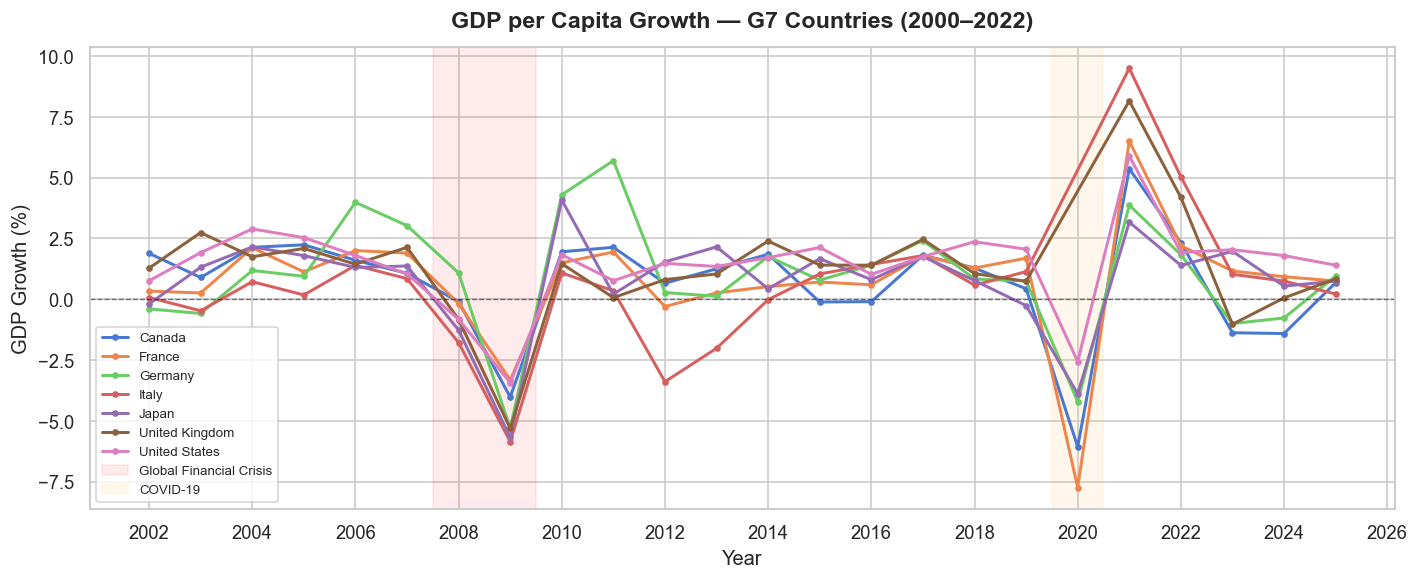

Insight: The 2008 crisis and COVID-19 caused synchronized contractions across all G7 economies, with Italy and the UK showing the slowest recovery after 2008.


In [41]:
# moving to some visualizations
# chart 1: GDP growth over time (G7 countries)
# create the charts folder if it doesn't exist yet
os.makedirs("charts", exist_ok=True)

# define our G7 list, the names are taken from our dataset
g7 = ["United States", "United Kingdom", "Germany", "France",
      "Italy", "Japan", "Canada"]

# filter the DataFrame: keep only rows where the country column is in our g7 list
df_g7 = df_clean[df_clean["country"].isin(g7)] # .isin() checks each value against a list and returns True/False

fig, ax = plt.subplots(figsize=(12, 5)) # fig = the whole canvas; ax = the chart inside it
# plt.subplots() creates a figure and one set of axes (the actual chart area)
# figsize=(12, 5) sets the width and height in inches

# loop through each country and draw one line per country
for country, group in df_g7.groupby("country"): # .groupby("country") splits the data into one group per country
    # each iteration gives us a country name and a DataFrame of just that country's rows
    ax.plot(
        group["year"],        # X-axis: years
        group["gdp_growth"],  # Y-axis: GDP growth values
        marker="o",           # draw a circle dot at each data point
        markersize=3,         # size of the dot
        label=country,        # this text appears in the legend
        linewidth=1.8         # thickness of the line
    )

# draw a horizontal dashed line at y=0 to make it easy to see negative growth
# color, linewidth, linestyle, alpha (opacity 0=invisible, 1=solid) are style params
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
# axvspan() shades a vertical band between two x-values
# we use this to highlight the Global Financial Crisis years
ax.axvspan(2007.5, 2009.5, color="red", alpha=0.08, label="Global Financial Crisis")
ax.axvspan(2019.5, 2020.5, color="orange", alpha=0.08, label="COVID-19")

# chart labels and title
ax.set_title("GDP per Capita Growth — G7 Countries (2000–2022)",
             fontsize=14, fontweight="bold", pad=12) # pad=12 adds space between the title and the chart so they don't overlap
ax.set_xlabel("Year")
ax.set_ylabel("GDP Growth (%)")
ax.legend(loc="lower left", fontsize=8) # ax.legend() draws the legend box using the label= values we set above
ax.xaxis.set_major_locator(mticker.MultipleLocator(2)) # set x-axis ticks every 2 years so it's not too crowded

plt.tight_layout() # plt.tight_layout() automatically adjusts spacing so nothing gets cut off
plt.savefig("charts/01_gdp_growth_g7.png") # save the chart as a PNG image file in the charts folder
plt.show() # display the chart in the notebook

print("Insight: The 2008 crisis and COVID-19 caused synchronized contractions across "
      "all G7 economies, with Italy and the UK showing the slowest recovery after 2008.")

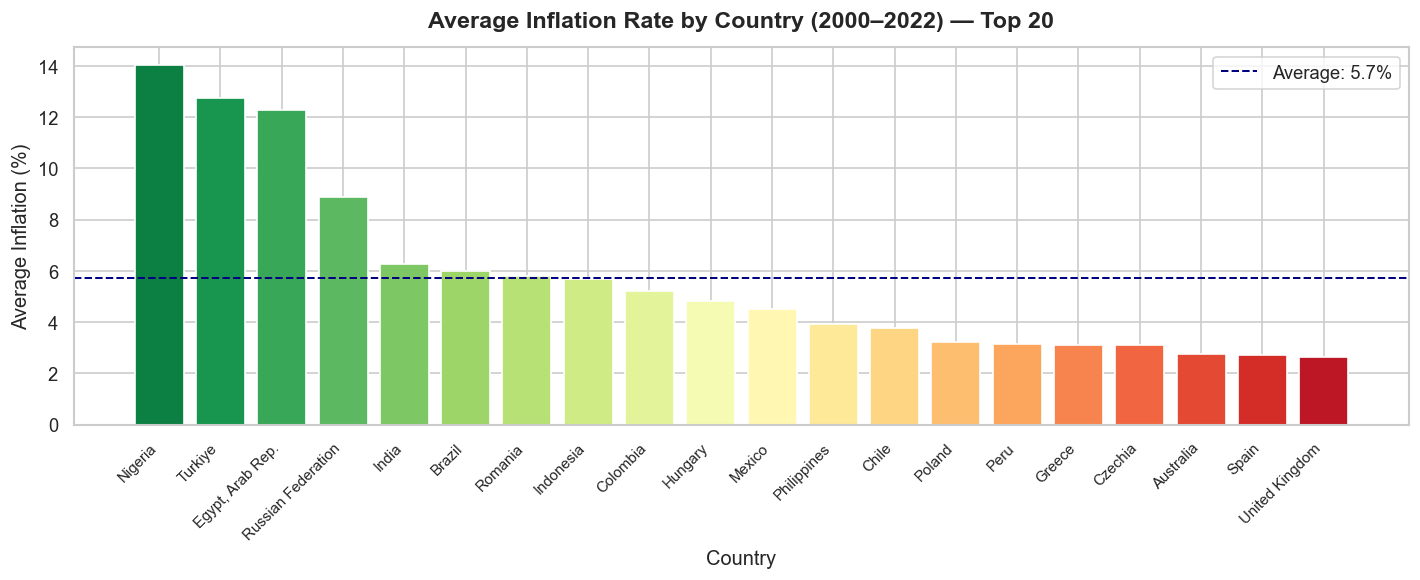

Insight: Emerging economies consistently show higher average inflation than developed ones, reflecting structural differences in monetary policy credibility and currency stability.


In [42]:
# chart 2: Average inflation by country
avg_inflation = (
    df_clean.groupby("country")["inflation"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(avg_inflation.index, avg_inflation.values,
       color=sns.color_palette("RdYlGn_r", len(avg_inflation)))
# ax.bar() draws a bar chart
# avg_inflation.index = country names (x-axis labels)
# avg_inflation.values = the actual numbers (bar heights)
# color= uses seaborn's color_palette to create a gradient from red to green
# "RdYlGn_r" = Red-Yellow-Green reversed (high = red = bad, low = green = ok)

ax.axhline(avg_inflation.mean(), color="navy", linestyle="--", linewidth=1.2,
           label=f"Average: {avg_inflation.mean():.1f}%")
# draw a horizontal line at the average of the top-20 averages
# we use an f-string to embed the actual value in the label text

ax.set_title("Average Inflation Rate by Country (2000–2022) — Top 20",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Country")
ax.set_ylabel("Average Inflation (%)")
ax.legend()
plt.xticks(rotation=45, ha="right", fontsize=9)
# rotate the x-axis labels 45 degrees so they don't overlap each other
# ha="right" = "horizontal alignment right" — anchors the rotated text neatly

plt.tight_layout()
plt.savefig("charts/02_avg_inflation_by_country.png")
plt.show()

print("Insight: Emerging economies consistently show higher average inflation than "
      "developed ones, reflecting structural differences in monetary policy credibility "
      "and currency stability.")


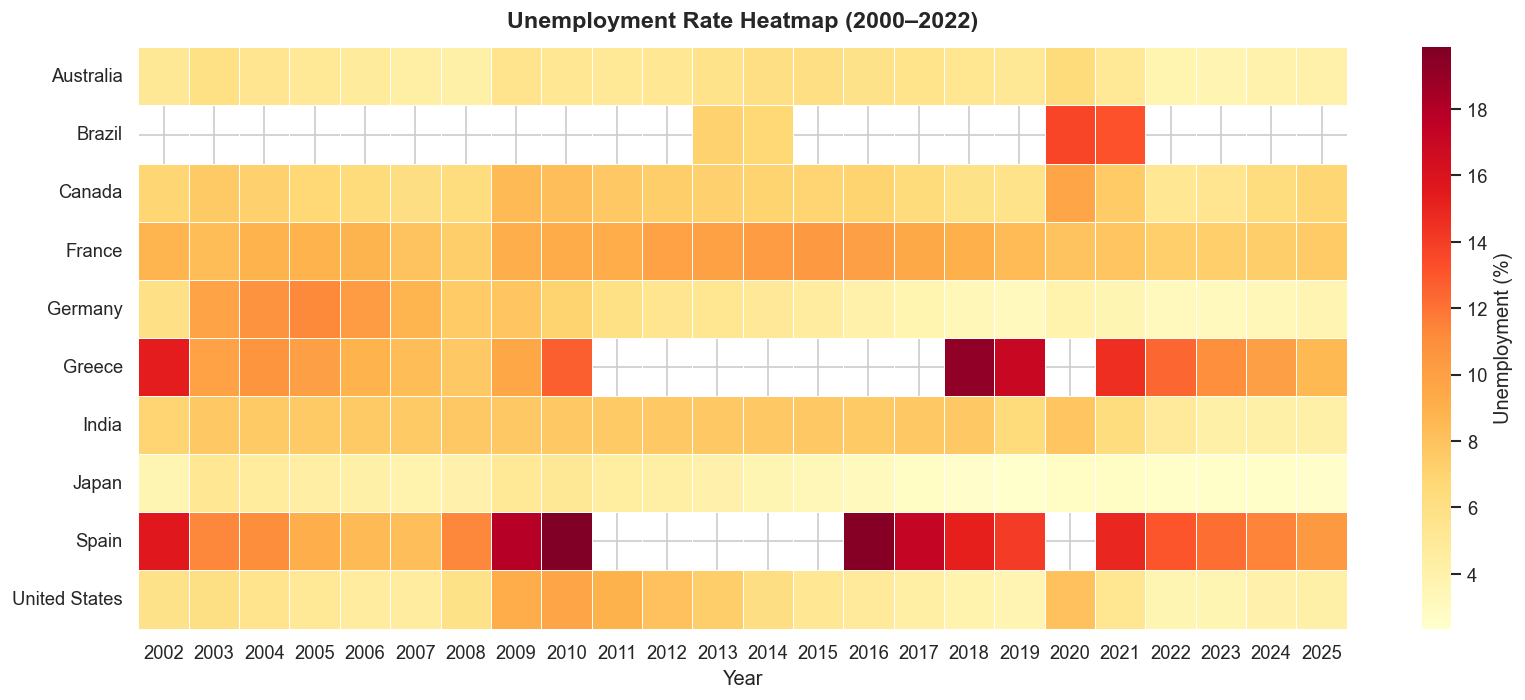

Insight: Greece and Spain show dramatically elevated unemployment after 2010, a direct consequence of the Eurozone debt crisis and austerity measures.


In [43]:
# chart 3: Unemployment heatmap
# pick a representative set of 12 countries from different regions/income levels
selected = [
    "United States", "Germany", "France", "Spain", "Greece",
    "Japan", "Brazil", "South Africa", "India", "Australia",
    "Canada", "Turkey"
]

# filter the main DataFrame to only these countries
df_sel = df_clean[df_clean["country"].isin(selected)]

pivot = df_sel.pivot_table(
    # pivot_table() reshapes the data so:
    index="country",        # rows = countries (index)
    columns="year",         # columns = years
    values="unemployment"   # values = unemployment rate
)
# this creates the matrix format that a heatmap needs

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(                                # sns.heatmap() draws a color-coded grid where color = value intensity
    pivot,
    cmap="YlOrRd",                          # cmap="YlOrRd" = Yellow-Orange-Red color scale (light = low, dark = high unemployment)
    ax=ax,
    linewidths=0.3,                         # linewidths=0.3 = thin white lines between cells so each cell is distinct
    cbar_kws={"label": "Unemployment (%)"}, # cbar_kws = extra settings for the colorbar (the legend on the right)
    annot=False                             # annot=False = don't print the numbers inside each cell (too small to read)
)

ax.set_title("Unemployment Rate Heatmap (2000–2022)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("") # no y-axis label needed — country names are self-explanatory

plt.tight_layout()
plt.savefig("charts/03_unemployment_heatmap.png")
plt.show()

print("Insight: Greece and Spain show dramatically elevated unemployment after 2010, "
      "a direct consequence of the Eurozone debt crisis and austerity measures.")

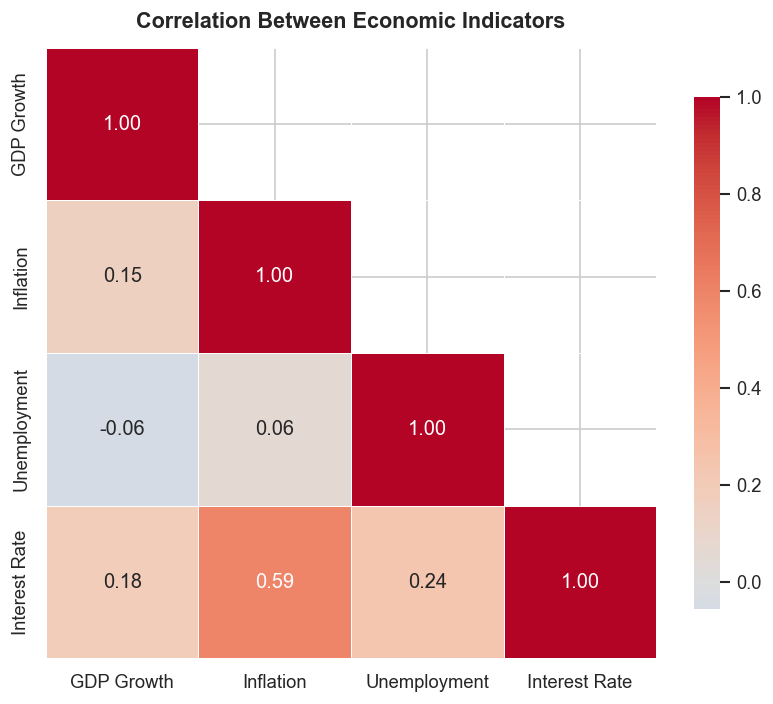

Insight: GDP growth and unemployment show a negative correlation, consistent with Okun's Law. Inflation and interest rates show a positive correlation, reflecting central bank policy responses.


In [44]:
# chart 4: Correlation matrix
corr = df_clean[["gdp_growth", "inflation", "unemployment", "interest_rate"]].corr()
# we take only the 4 columns from df_clean of which, we are going to look at the correlation
# .corr() computes the pairwise correlation coefficient between all numeric columns
# correlation ranges from -1 to +1:
# +1 = perfect positive relationship (when one goes up, the other goes up)
# 0 = no relationship
# -1 = perfect negative relationship (when one goes up, the other goes down)
# now we have a square matrix — the row labels and column labels are identical

labels = {
    "gdp_growth":    "GDP Growth",
    "inflation":     "Inflation",
    "unemployment":  "Unemployment",
    "interest_rate": "Interest Rate"
}
# create friendlier display names for the heatmap labels
# to replace both row and column index names with the friendly versions
corr.index = corr.columns = [labels[c] for c in corr.index]
# this loops through the current row labels (corr.index) and for each one looks up its friendly name in the dictionary
# then we assign that list to both corr.index and corr.columns at the same time

fig, ax = plt.subplots(figsize=(7, 6))

mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
# create a "mask" — a True/False matrix the same shape as our correlation matrix
# we'll use this to hide the upper triangle (it's a mirror of the lower triangle showing both would be redundant)
mask_array = mask.values.copy()
mask_array[np.triu_indices_from(mask_array, k=1)] = True
mask = pd.DataFrame(mask_array, index=corr.index, columns=corr.columns)
# np.triu_indices_from() returns the indices of the upper triangle of a matrix
# k=1 means exclude the diagonal (we want to keep the diagonal values visible)

sns.heatmap(
    corr,
    annot=True,                 # print the correlation number inside each cell
    fmt=".2f",                  # format numbers with 2 decimal places
    cmap="coolwarm",            # blue = negative correlation, Red = positive correlation
    center=0,                   # center the color scale at 0 (no correlation = white/neutral)
    ax=ax,
    square=True,                # make each cell square instead of rectangular
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},   # make the colorbar slightly smaller
    mask=mask                   # hide the upper triangle
)

ax.set_title("Correlation Between Economic Indicators",
             fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("charts/04_correlation_matrix.png")
plt.show()

print("Insight: GDP growth and unemployment show a negative correlation, consistent "
      "with Okun's Law. Inflation and interest rates show a positive correlation, "
      "reflecting central bank policy responses.")

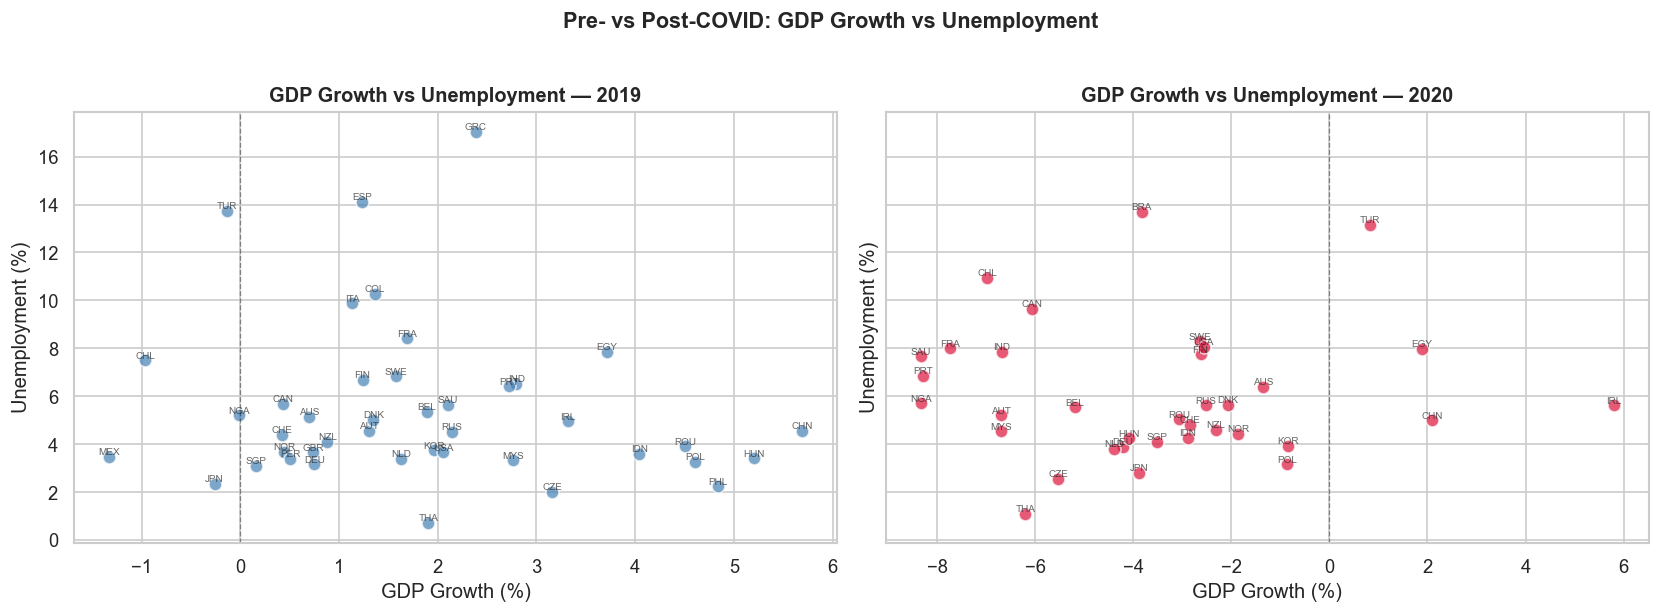

Insight: COVID-19 shifted nearly every country leftward (negative GDP growth) in 2020. Countries with already-high unemployment were hit particularly hard.


In [45]:
# chart 5: GDP vs Unemployment (2019 vs 2020)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
# we compare two years side by side to visualise the COVID impact
# plt.subplots(1, 2) creates 1 row and 2 columns of charts side by side
# sharey=True means both charts share the same y-axis scale — essential for fair comparison

for ax, year, color in zip(axes, [2019, 2020], ["steelblue", "crimson"]):
    # zip() pairs three lists together so we can loop through all three at once
    # each iteration: ax = one chart panel, year = the year, color = that year's color
    sub = df_clean[
        df_clean["year"] == year
    ].dropna(subset=["gdp_growth", "unemployment"])
    # filter to just this year, and only rows that have both values we need
    # .dropna(subset=[...]) removes rows where either column is missing

    ax.scatter(sub["gdp_growth"], sub["unemployment"],
               alpha=0.7, color=color, edgecolors="white", s=60)
    # ax.scatter() draws a scatter plot — one dot per country
    # alpha=0.7 = 70% opacity (slight transparency so overlapping dots are visible)
    # edgecolors="white" = thin white border around each dot
    # s=60 = size of each dot

    for _, row in sub.iterrows():
        ax.annotate(row["country_code"],
                    # text to display
                    (row["gdp_growth"], row["unemployment"]),
                    # position (x, y)
                    fontsize=6, alpha=0.7, ha="center", va="bottom") # horizontal & vertical alignment
                    # add a country code label next to each dot
                    # iterrows() loops through the DataFrame one row at a time,
                    # giving us both the index (we ignore with _) and the row data

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    # vertical line at x=0 to separate positive and negative GDP growth
    ax.set_title(f"GDP Growth vs Unemployment — {year}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("GDP Growth (%)")
    ax.set_ylabel("Unemployment (%)")

plt.suptitle("Pre- vs Post-COVID: GDP Growth vs Unemployment",
             fontsize=13, fontweight="bold", y=1.02)
# suptitle() adds a single title above all subplots
# y=1.02 moves it slightly above the charts so it doesn't overlap
plt.tight_layout()
plt.savefig("charts/05_gdp_vs_unemployment_covid.png", bbox_inches="tight")
# bbox_inches="tight" ensures the suptitle isn't cropped when saving
plt.show()

print("Insight: COVID-19 shifted nearly every country leftward (negative GDP growth) "
      "in 2020. Countries with already-high unemployment were hit particularly hard.")

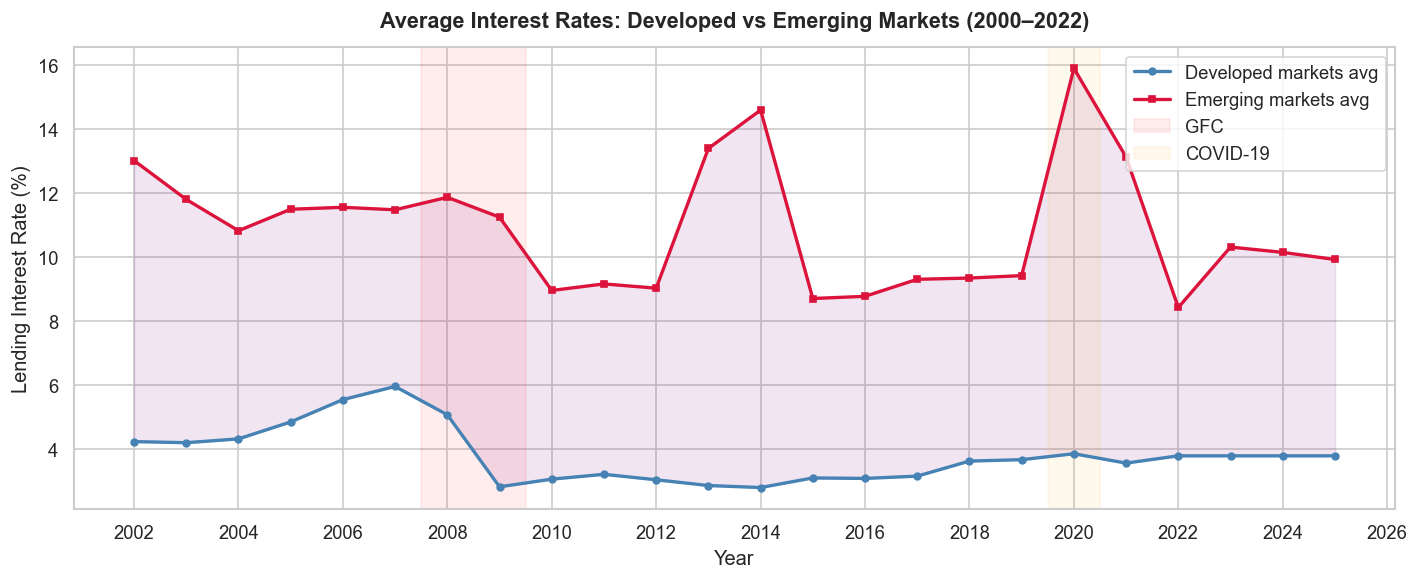

Insight: Emerging markets maintain persistently higher interest rates than developed ones, reflecting higher inflation expectations and currency risk premiums.


In [60]:
# chart 6: Interest Rates — developed vs emerging
# define our two groups of countries
developed = ["United States", "Germany", "United Kingdom", "Japan",
             "Canada", "Australia", "France"]
emerging  = ["Brazil", "Turkey", "India", "South Africa",
             "Mexico", "Indonesia", "Argentina"]

df_dev = df_clean[df_clean["country"].isin(developed)].groupby("year")["interest_rate"].mean()
df_eme = df_clean[df_clean["country"].isin(emerging)].groupby("year")["interest_rate"].mean()
# for each group, filter the data and calculate the yearly average interest rate
# .groupby("year") groups all countries' data by year
# ["interest_rate"].mean() computes the average across all countries for each year
# the result is a Series where the index is year and the value is the average rate

fig, ax = plt.subplots(figsize=(12, 5))

# plot both lines on the same axes
ax.plot(df_dev.index, df_dev.values, marker="o", markersize=4,
        label="Developed markets avg", color="steelblue", linewidth=2)
ax.plot(df_eme.index, df_eme.values, marker="s", markersize=4,
        label="Emerging markets avg", color="crimson", linewidth=2) # square marker (instead of circle)
ax.fill_between(df_dev.index, df_dev.values, df_eme.values,
                alpha=0.1, color="purple")
# fill_between() shades the area between the two lines
# this visually emphasises the gap between the two groups
# alpha=0.1 = very transparent fill

# shade crisis periods again for context
ax.axvspan(2007.5, 2009.5, color="red", alpha=0.07, label="GFC")
ax.axvspan(2019.5, 2020.5, color="orange", alpha=0.07, label="COVID-19")

ax.set_title("Average Interest Rates: Developed vs Emerging Markets (2000–2022)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Lending Interest Rate (%)")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig("charts/06_interest_rates_dev_vs_emerging.png")
plt.show()

print("Insight: Emerging markets maintain persistently higher interest rates than "
      "developed ones, reflecting higher inflation expectations and currency risk premiums.")


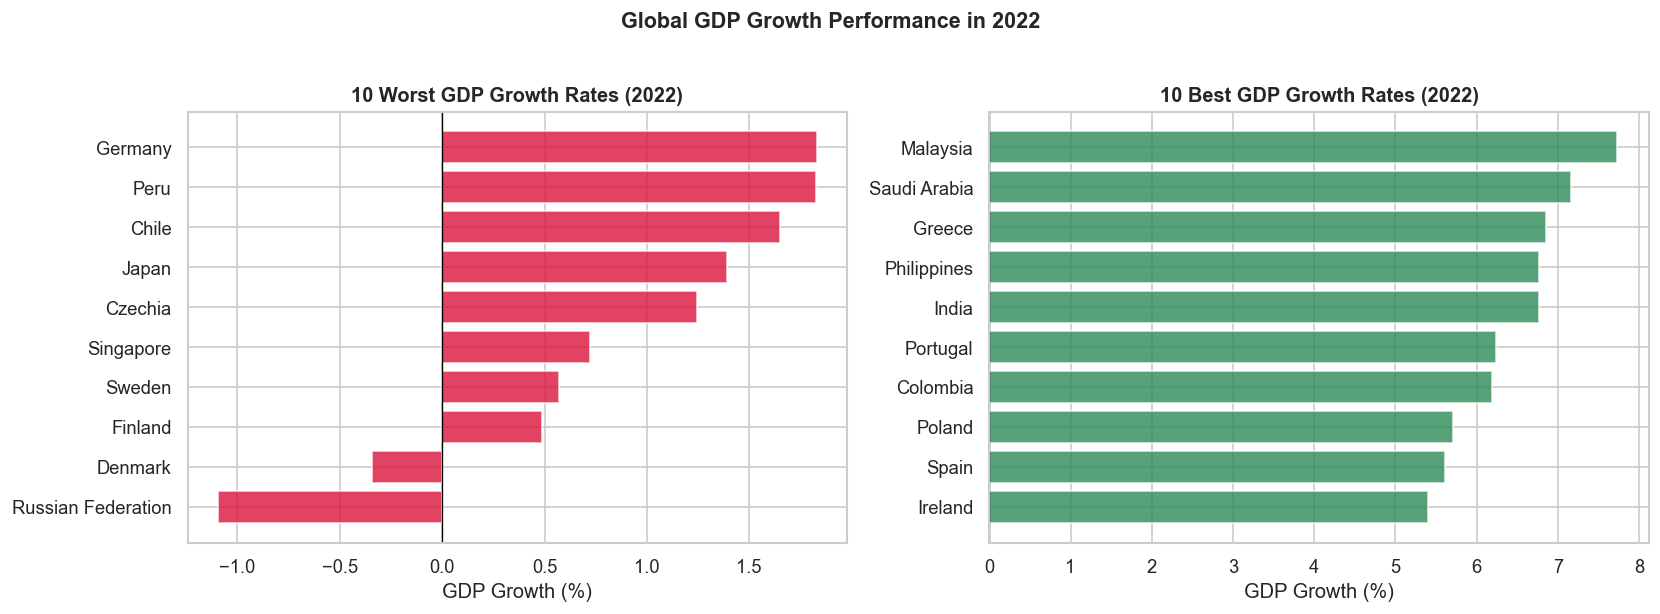

Insight: 2022 shows a highly uneven global recovery — energy-exporting nations rebounded strongly while countries facing debt crises or political instability lagged significantly.


In [61]:
# chart 7: Top & bottom GDP performers 2022
latest = (
    df_clean[df_clean["year"] == 2022]
    .dropna(subset=["gdp_growth"])
    .sort_values("gdp_growth")
)
# filter to 2022 only, drop rows with no GDP data, sort ascending (lowest first)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots(1, 2) = 1 row, 2 side-by-side charts

# --- bottom 10 (worst performers) ---
bottom10 = latest.head(10)  # .head(10) gives the first 10 rows = lowest GDP growth
axes[0].barh(
    bottom10["country"],    # barh = horizontal bar chart; country names on y-axis
    bottom10["gdp_growth"],
    color="crimson",
    alpha=0.8
)
axes[0].axvline(0, color="black", linewidth=0.8)  # line at zero for reference
axes[0].set_title("10 Worst GDP Growth Rates (2022)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("GDP Growth (%)")
 
# --- top 10 (best performers) ---
top10 = latest.tail(10)  # .tail(10) gives the last 10 rows = highest GDP growth
axes[1].barh(
    top10["country"],
    top10["gdp_growth"],
    color="seagreen",
    alpha=0.8
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("10 Best GDP Growth Rates (2022)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("GDP Growth (%)")
 
plt.suptitle("Global GDP Growth Performance in 2022",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/07_gdp_top_bottom_2022.png", bbox_inches="tight")
plt.show()
 
print("Insight: 2022 shows a highly uneven global recovery — energy-exporting nations "
      "rebounded strongly while countries facing debt crises or political instability "
      "lagged significantly.")

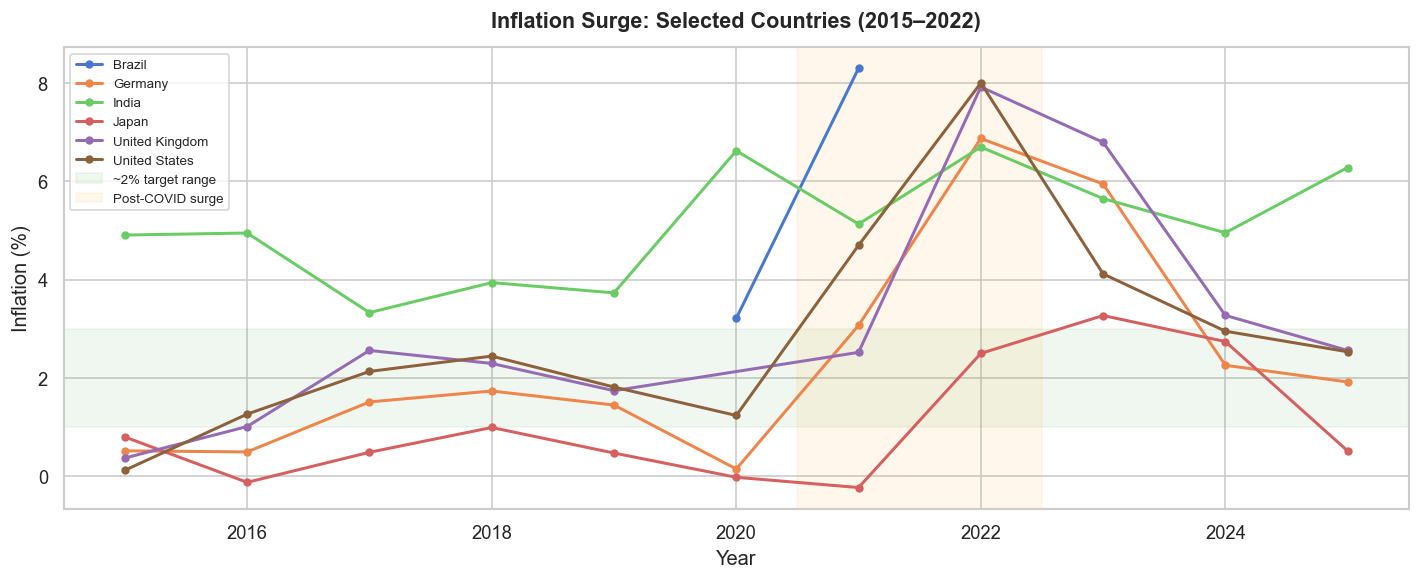

Insight: Post-COVID inflation surged globally in 2021–2022, driven by supply chain disruptions, energy prices, and fiscal stimulus. Turkey was an extreme outlier due to unconventional monetary policy.


In [64]:
# chart 8: Inflation surge 2021-2022
# select 8 countries that tell an interesting story about the inflation surge
focus = ["United States", "Germany", "United Kingdom",
         "Brazil", "Turkey", "Japan", "India", "South Africa"]

df_inf = df_clean[
    df_clean["country"].isin(focus) &
    (df_clean["year"] >= 2015)
]
# filter to: only our focus countries AND only years from 2015 onward

fig, ax = plt.subplots(figsize=(12, 5))

for country, group in df_inf.groupby("country"):
    ax.plot(group["year"], group["inflation"],
            marker="o", markersize=4, label=country, linewidth=1.8)
            # plot one line per country

ax.axhspan(1, 3, color="green", alpha=0.06, label="~2% target range")
# shade the "normal" 2% central bank target band in light green
# most central banks (Fed, ECB, Bank of England) target ~2% inflation
ax.axvspan(2020.5, 2022.5, color="orange", alpha=0.08, label="Post-COVID surge")
# highlight the post-COVID period when inflation surged globally

ax.set_title("Inflation Surge: Selected Countries (2015–2022)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Inflation (%)")
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("charts/08_inflation_surge.png")
plt.show()

print("Insight: Post-COVID inflation surged globally in 2021–2022, driven by supply "
      "chain disruptions, energy prices, and fiscal stimulus. Turkey was an extreme "
      "outlier due to unconventional monetary policy.")